# Grid World 15x15 — Value Iteration (Reinforcement Learning)

Este notebook construye un grid de 15x15 con 5 obstáculos, un inicio y un final,
y resuelve la mejor ruta usando **Value Iteration** (método de programación dinámica
para Reinforcement Learning). Se muestra:

- La evolución de la función de valor `V(s)` iteración por iteración.
- La política óptima de dirección (flechas) obtenida a partir de `V`.
- El camino óptimo trazado desde el inicio hasta el final.
- La curva de convergencia del algoritmo.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

## 1. Configuración del entorno

In [ ]:
GRID_SIZE = 15
START = (0, 0)
GOAL = (14, 14)
N_OBSTACLES = 5

GAMMA = 0.9          # factor de descuento
THETA = 1e-4         # umbral de convergencia
REWARD_GOAL = 10
REWARD_STEP = -0.1
REWARD_OBSTACLE = -5

ACTIONS = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1),
}
ACTION_ARROWS = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→'}


def generate_obstacles(n, start, goal, size):
    """Genera n obstaculos aleatorios que no coincidan con inicio ni fin."""
    obstacles = set()
    while len(obstacles) < n:
        pos = (random.randint(0, size - 1), random.randint(0, size - 1))
        if pos != start and pos != goal:
            obstacles.add(pos)
    return obstacles


OBSTACLES = generate_obstacles(N_OBSTACLES, START, GOAL, GRID_SIZE)
print("Obstaculos:", sorted(OBSTACLES))


def is_valid(pos):
    r, c = pos
    return 0 <= r < GRID_SIZE and 0 <= c < GRID_SIZE


def get_reward(pos):
    if pos == GOAL:
        return REWARD_GOAL
    if pos in OBSTACLES:
        return REWARD_OBSTACLE
    return REWARD_STEP

Obstaculos: [(0, 11), (3, 2), (4, 3), (10, 1), (11, 1)]


## 2. Value Iteration

Actualiza `V(s) = max_a [ R(s') + γ·V(s') ]` hasta que el cambio máximo (`delta`) sea menor a `THETA`.

In [ ]:
def value_iteration():
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    history = []          # V despues de cada iteracion (para graficar avance)
    iteration = 0

    while True:
        delta = 0
        V_new = np.copy(V)

        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                pos = (r, c)
                if pos == GOAL or pos in OBSTACLES:
                    continue  # estados terminales / bloqueados no se actualizan

                action_values = []
                for a, (dr, dc) in ACTIONS.items():
                    next_pos = (r + dr, c + dc)
                    if not is_valid(next_pos) or next_pos in OBSTACLES:
                        next_pos = pos  # chocar con muro/obstaculo = quedarse
                    reward = get_reward(next_pos)
                    action_values.append(reward + GAMMA * V[next_pos])

                V_new[r, c] = max(action_values)
                delta = max(delta, abs(V_new[r, c] - V[r, c]))

        V = V_new
        history.append(V.copy())
        iteration += 1

        print(f"Iteracion {iteration:3d} | delta = {delta:.6f}")

        if delta < THETA:
            break

    return V, history, iteration


V, history, n_iterations = value_iteration()
print(f"\nConvergencia total en {n_iterations} iteraciones")

Iteracion   1 | delta = 10.000000
Iteracion   2 | delta = 9.000000
Iteracion   3 | delta = 8.100000
Iteracion   4 | delta = 7.290000
Iteracion   5 | delta = 6.561000
Iteracion   6 | delta = 5.904900
Iteracion   7 | delta = 5.314410
Iteracion   8 | delta = 4.782969
Iteracion   9 | delta = 4.304672
Iteracion  10 | delta = 3.874205
Iteracion  11 | delta = 3.486784
Iteracion  12 | delta = 3.138106
Iteracion  13 | delta = 2.824295
Iteracion  14 | delta = 2.541866
Iteracion  15 | delta = 2.287679
Iteracion  16 | delta = 2.058911
Iteracion  17 | delta = 1.853020
Iteracion  18 | delta = 1.667718
Iteracion  19 | delta = 1.500946
Iteracion  20 | delta = 1.350852
Iteracion  21 | delta = 1.215767
Iteracion  22 | delta = 1.094190
Iteracion  23 | delta = 0.984771
Iteracion  24 | delta = 0.886294
Iteracion  25 | delta = 0.797664
Iteracion  26 | delta = 0.717898
Iteracion  27 | delta = 0.646108
Iteracion  28 | delta = 0.581497
Iteracion  29 | delta = 0.000000

Convergencia total en 29 iteraciones


## 3. Política óptima y camino

In [ ]:
def extract_policy(V):
    """Politica de direccion: en cada estado, la accion que maximiza el valor."""
    policy = {}
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            pos = (r, c)
            if pos == GOAL or pos in OBSTACLES:
                continue

            best_action, best_value = None, -np.inf
            for a, (dr, dc) in ACTIONS.items():
                next_pos = (r + dr, c + dc)
                if not is_valid(next_pos) or next_pos in OBSTACLES:
                    next_pos = pos
                val = get_reward(next_pos) + GAMMA * V[next_pos]
                if val > best_value:
                    best_value, best_action = val, a
            policy[pos] = best_action
    return policy


def trace_path(policy, start, goal, max_steps=500):
    path = [start]
    pos = start
    steps = 0
    while pos != goal and steps < max_steps:
        action = policy.get(pos)
        if action is None:
            break
        dr, dc = ACTIONS[action]
        next_pos = (pos[0] + dr, pos[1] + dc)
        if not is_valid(next_pos) or next_pos in OBSTACLES:
            break
        path.append(next_pos)
        pos = next_pos
        steps += 1
    return path


policy = extract_policy(V)
path = trace_path(policy, START, GOAL)

print(f"Longitud del camino optimo encontrado: {len(path) - 1} pasos")

Longitud del camino optimo encontrado: 28 pasos


## 4. Visualización: grid + política + camino, y curva de convergencia

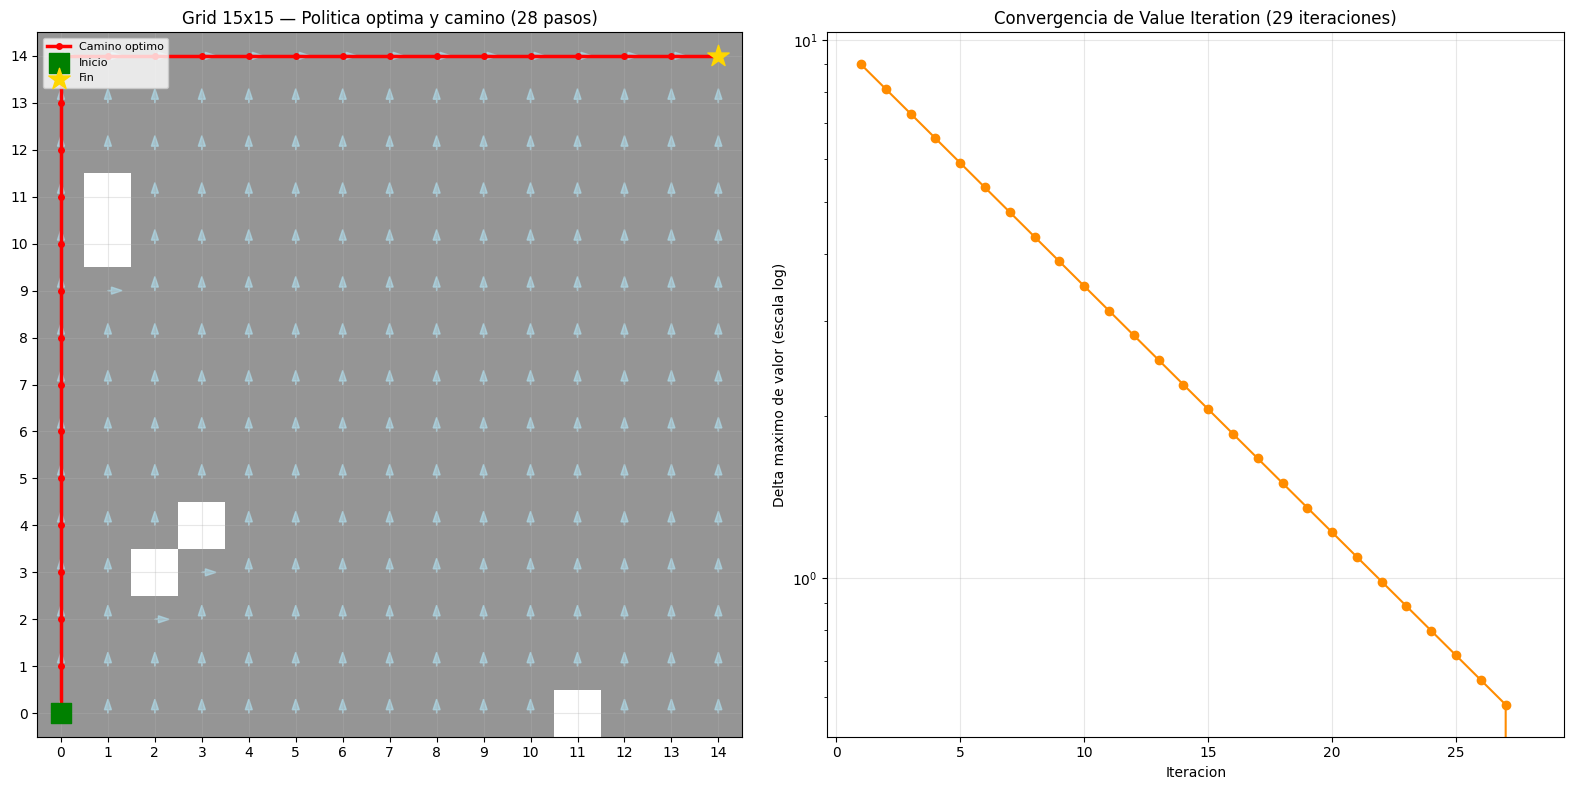

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1) Grid con politica (flechas) y camino optimo resaltado
ax = axes[0]
grid_display = np.zeros((GRID_SIZE, GRID_SIZE))
for obs in OBSTACLES:
    grid_display[obs] = -1
ax.imshow(grid_display, cmap='Greys', vmin=-1, vmax=1)

for pos, action in policy.items():
    dr, dc = ACTIONS[action]
    ax.arrow(pos[1], pos[0], dc * 0.3, dr * 0.3,
              head_width=0.15, color='lightblue', alpha=0.7, length_includes_head=True)

path_rows = [p[0] for p in path]
path_cols = [p[1] for p in path]
ax.plot(path_cols, path_rows, color='red', linewidth=2.5, marker='o', markersize=4, label='Camino optimo')

ax.scatter([START[1]], [START[0]], color='green', s=220, marker='s', label='Inicio', zorder=5)
ax.scatter([GOAL[1]], [GOAL[0]], color='gold', s=260, marker='*', label='Fin', zorder=5)

ax.set_title(f'Grid 15x15 — Politica optima y camino ({len(path) - 1} pasos)')
ax.legend(loc='upper left', fontsize=8)
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.grid(True, alpha=0.3)
ax.invert_yaxis()

# 2) Curva de convergencia (avance del aprendizaje por iteracion)
ax2 = axes[1]
max_deltas = [np.max(np.abs(history[i] - history[i - 1])) for i in range(1, len(history))]
ax2.plot(range(1, len(max_deltas) + 1), max_deltas, marker='o', color='darkorange')
ax2.set_xlabel('Iteracion')
ax2.set_ylabel('Delta maximo de valor (escala log)')
ax2.set_title(f'Convergencia de Value Iteration ({n_iterations} iteraciones)')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Valores finales y política en texto

In [ ]:
print("Valores finales V(s) (redondeados):")
print(np.round(V, 2))

print("\nPolitica optima (flechas por celda):")
for r in range(GRID_SIZE):
    row = ""
    for c in range(GRID_SIZE):
        pos = (r, c)
        if pos == GOAL:
            row += " G "
        elif pos in OBSTACLES:
            row += " X "
        else:
            row += f" {ACTION_ARROWS[policy[pos]]} "
    print(row)

Valores finales V(s) (redondeados):
[[-0.36 -0.29 -0.21 -0.12 -0.03  0.08  0.2   0.34  0.49  0.65  0.83  0.
   1.26  1.52  1.8 ]
 [-0.29 -0.21 -0.12 -0.03  0.08  0.2   0.34  0.49  0.65  0.83  1.04  1.26
   1.52  1.8   2.11]
 [-0.21 -0.12 -0.03  0.08  0.2   0.34  0.49  0.65  0.83  1.04  1.26  1.52
   1.8   2.11  2.45]
 [-0.12 -0.03  0.    0.2   0.34  0.49  0.65  0.83  1.04  1.26  1.52  1.8
   2.11  2.45  2.84]
 [-0.03  0.08  0.2   0.    0.49  0.65  0.83  1.04  1.26  1.52  1.8   2.11
   2.45  2.84  3.26]
 [ 0.08  0.2   0.34  0.49  0.65  0.83  1.04  1.26  1.52  1.8   2.11  2.45
   2.84  3.26  3.74]
 [ 0.2   0.34  0.49  0.65  0.83  1.04  1.26  1.52  1.8   2.11  2.45  2.84
   3.26  3.74  4.26]
 [ 0.34  0.49  0.65  0.83  1.04  1.26  1.52  1.8   2.11  2.45  2.84  3.26
   3.74  4.26  4.85]
 [ 0.49  0.65  0.83  1.04  1.26  1.52  1.8   2.11  2.45  2.84  3.26  3.74
   4.26  4.85  5.5 ]
 [ 0.65  0.83  1.04  1.26  1.52  1.8   2.11  2.45  2.84  3.26  3.74  4.26
   4.85  5.5   6.22]
 [ 0.83  0.    1.

# Parte 2: Implementación Q-Learning

In [7]:
#Funcioens de Q Learning
import time

# ------------------------------- Q-Learning -------------------------------
ALPHA = 0.1          # Tasa de aprendizaje
EPSILON_START = 1.0  # Exploracion inicial
EPSILON_MIN = 0.01   # Exploracion minima
EPSILON_DECAY = 0.995 # Decaimiento por episodio
N_EPISODES = 1000    # Cantidad de episodios de entrenamiento
MAX_STEPS_EP = 300   # Pasos maximos por episodio

ACTION_LIST = list(ACTIONS.keys())

def q_learning():
    """Entrena una matriz Q(s, a) usando Q-Learning."""
    # Matriz Q inicializada en ceros: [filas, columnas, num_acciones]
    Q = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION_LIST)))
    epsilon = EPSILON_START

    # Historial para medir rendimiento durante el entrenamiento
    rewards_per_episode = []

    for episode in range(N_EPISODES):
        pos = START
        total_reward = 0

        for step in range(MAX_STEPS_EP):
            if pos == GOAL:
                break

            # Seleccion de accion (Epsilon-Greedy)
            if random.random() < epsilon:
                action_idx = random.randint(0, len(ACTION_LIST) - 1)
            else:
                action_idx = np.argmax(Q[pos[0], pos[1]])

            action = ACTION_LIST[action_idx]
            dr, dc = ACTIONS[action]
            next_pos = (pos[0] + dr, pos[1] + dc)

            # Validacion de limites y obstaculos
            if not is_valid(next_pos) or next_pos in OBSTACLES:
                next_pos = pos  # Colision = quedarse en la misma celda

            reward = get_reward(next_pos)
            total_reward += reward

            # Actualizacion Q-Learning: Q(s,a) = Q(s,a) + alpha * [R + gamma * max(Q(s',a')) - Q(s,a)]
            best_next_action = np.argmax(Q[next_pos[0], next_pos[1]])
            td_target = reward + GAMMA * Q[next_pos[0], next_pos[1], best_next_action]
            td_error = td_target - Q[pos[0], pos[1], action_idx]

            Q[pos[0], pos[1], action_idx] += ALPHA * td_error
            pos = next_pos

        rewards_per_episode.append(total_reward)
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    return Q, rewards_per_episode

def extract_policy_from_q(Q):
    """Extrae la politica optima a partir de la matriz Q."""
    policy = {}
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            pos = (r, c)
            if pos == GOAL or pos in OBSTACLES:
                continue
            best_action_idx = np.argmax(Q[r, c])
            policy[pos] = ACTION_LIST[best_action_idx]
    return policy

In [8]:
# --------------------- Ejecucion y Benchmark Comparativo ---------------------
print("--- 1. Ejecutando Value Iteration ---")
t0 = time.time()
V_vi, history_vi, n_iter_vi = value_iteration()
t_vi = time.time() - t0
policy_vi = extract_policy(V_vi)
path_vi = trace_path(policy_vi, START, GOAL)

print("\n--- 2. Ejecutando Q-Learning ---")
t0 = time.time()
Q_table, q_rewards = q_learning()
t_ql = time.time() - t0
policy_ql = extract_policy_from_q(Q_table)
path_ql = trace_path(policy_ql, START, GOAL)

# Tabla resumen en consola
print("\n" + "="*50)
print("             TABLA COMPARATIVA DE RESULTADOS")
print("="*50)
print(f"{'Metrica':<30} | {'Value Iteration':<15} | {'Q-Learning':<15}")
print("-" * 66)
print(f"{'Tiempo de ejecucion (s)':<30} | {t_vi:<15.4f} | {t_ql:<15.4f}")
print(f"{'Pasos camino optimo':<30} | {len(path_vi)-1:<15} | {len(path_ql)-1:<15}")
print(f"{'Unidad de entrenamiento':<30} | {f'{n_iter_vi} iteraciones':<15} | {f'{N_EPISODES} episodios':<15}")
print("="*50)

--- 1. Ejecutando Value Iteration ---
Iteracion   1 | delta = 10.000000
Iteracion   2 | delta = 9.000000
Iteracion   3 | delta = 8.100000
Iteracion   4 | delta = 7.290000
Iteracion   5 | delta = 6.561000
Iteracion   6 | delta = 5.904900
Iteracion   7 | delta = 5.314410
Iteracion   8 | delta = 4.782969
Iteracion   9 | delta = 4.304672
Iteracion  10 | delta = 3.874205
Iteracion  11 | delta = 3.486784
Iteracion  12 | delta = 3.138106
Iteracion  13 | delta = 2.824295
Iteracion  14 | delta = 2.541866
Iteracion  15 | delta = 2.287679
Iteracion  16 | delta = 2.058911
Iteracion  17 | delta = 1.853020
Iteracion  18 | delta = 1.667718
Iteracion  19 | delta = 1.500946
Iteracion  20 | delta = 1.350852
Iteracion  21 | delta = 1.215767
Iteracion  22 | delta = 1.094190
Iteracion  23 | delta = 0.984771
Iteracion  24 | delta = 0.886294
Iteracion  25 | delta = 0.797664
Iteracion  26 | delta = 0.717898
Iteracion  27 | delta = 0.646108
Iteracion  28 | delta = 0.581497
Iteracion  29 | delta = 0.000000

---

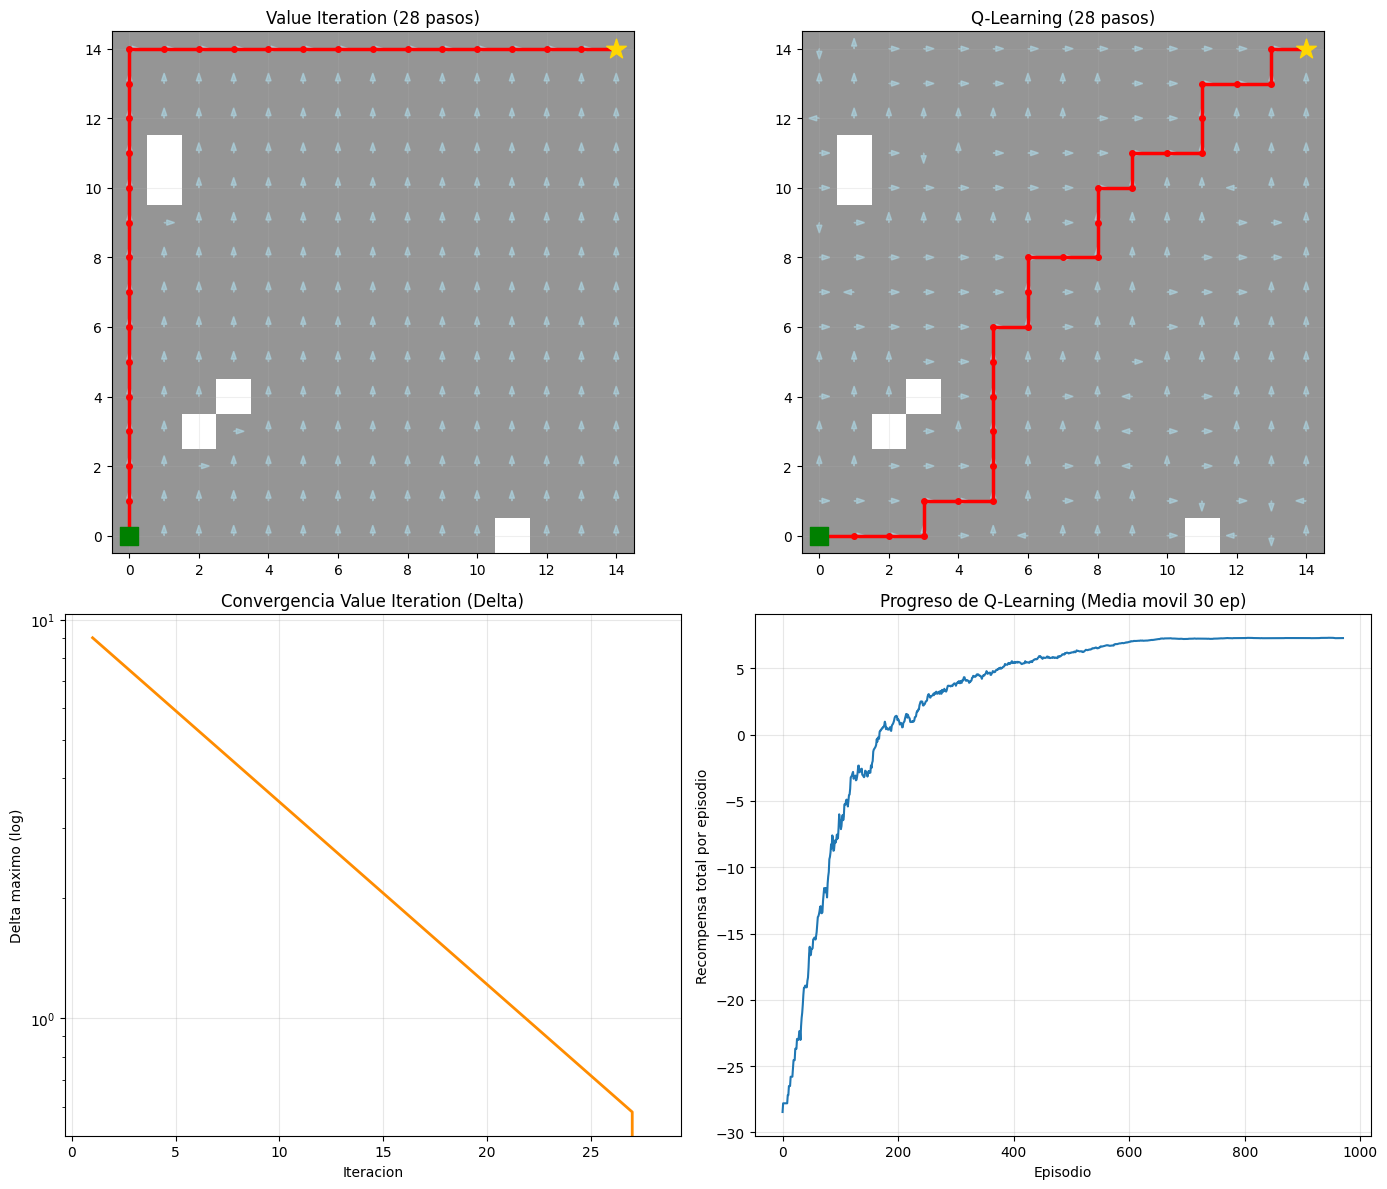

In [9]:
# ------------------------------ Plot Comparativo ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Preparar base de los mapas
grid_display = np.zeros((GRID_SIZE, GRID_SIZE))
for obs in OBSTACLES:
    grid_display[obs] = -1

# Mapas a graficar
policies = [policy_vi, policy_ql]
paths = [path_vi, path_ql]
titles = [f'Value Iteration ({len(path_vi)-1} pasos)', f'Q-Learning ({len(path_ql)-1} pasos)']

for idx in range(2):
    ax = axes[0, idx]
    ax.imshow(grid_display, cmap='Greys', vmin=-1, vmax=1)

    # Dibujar politica (flechas)
    for pos, action in policies[idx].items():
        dr, dc = ACTIONS[action]
        ax.arrow(pos[1], pos[0], dc * 0.3, dr * 0.3,
                 head_width=0.15, color='lightblue', alpha=0.6, length_includes_head=True)

    # Dibujar camino hallado
    p_rows = [p[0] for p in paths[idx]]
    p_cols = [p[1] for p in paths[idx]]
    ax.plot(p_cols, p_rows, color='red', linewidth=2.5, marker='o', markersize=4)

    ax.scatter([START[1]], [START[0]], color='green', s=180, marker='s', label='Inicio', zorder=5)
    ax.scatter([GOAL[1]], [GOAL[0]], color='gold', s=220, marker='*', label='Fin', zorder=5)
    ax.set_title(titles[idx])
    ax.invert_yaxis()
    ax.grid(True, alpha=0.2)

# Curva 1: Convergencia de Value Iteration
ax_vi = axes[1, 0]
max_deltas = [np.max(np.abs(history_vi[i] - history_vi[i - 1])) for i in range(1, len(history_vi))]
ax_vi.plot(range(1, len(max_deltas) + 1), max_deltas, color='darkorange', linewidth=2)
ax_vi.set_xlabel('Iteracion')
ax_vi.set_ylabel('Delta maximo (log)')
ax_vi.set_title('Convergencia Value Iteration (Delta)')
ax_vi.set_yscale('log')
ax_vi.grid(True, alpha=0.3)

# Curva 2: Progreso de Q-Learning (Recompensa Suavizada)
ax_ql = axes[1, 1]
window = 30  # Media movil para suavizar curva
smoothed_rewards = np.convolve(q_rewards, np.ones(window)/window, mode='valid')
ax_ql.plot(range(len(smoothed_rewards)), smoothed_rewards, color='tab:blue', linewidth=1.5)
ax_ql.set_xlabel('Episodio')
ax_ql.set_ylabel('Recompensa total por episodio')
ax_ql.set_title(f'Progreso de Q-Learning (Media movil {window} ep)')
ax_ql.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

💡 **Diferencias clave entre los métodos:**

**Value Iteration** (Modelo Dinámico): Conoce de antemano la matriz de transición y
las recompensas del entorno. Calcula la solución matemática exacta en pocas iteraciones globales.

**Q-Learning** (Model-Free / Muestreo): No asume conocimiento previo del mapa. Aprende interactuando por ensayo y error (Episodios). Requiere ajustar hiperparámetros como $\alpha$ (aprendizaje) y $\epsilon$ (exploración vs. explotación).